<a href="https://colab.research.google.com/github/amehta007/LSE-ME315/blob/main/ME315_Day01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ME315 Day 1 Workshop: Your First Machine Learning Workflow

**Course:** Machine Learning in Practice  
**Aim:** Use the California housing dataset to practise basic Python/Pandas commands, explore data, and complete a simple machine learning workflow.

This workshop is organised around three demonstration–activity cycles:

1. **Understanding the problem and the data**
2. **Exploring relationships in the data**
3. **Fitting and evaluating a first predictive model**

The focus is not on the theory of linear regression yet. We will study that properly in the next lectures. Today the aim is to see the workflow:

$$
\text{Problem} \rightarrow \text{Data} \rightarrow \text{Features} \rightarrow \text{Model} \rightarrow \text{Prediction} \rightarrow \text{Evaluation}.
$$

## Before we start: the modelling question

We will use data from California districts and try to predict **median house value**.

Think about the following questions before running any code.

1. Which variables do you expect to be useful for predicting house prices?
2. Which variables might be less useful?
3. What might make this prediction problem difficult?
4. Is this a regression problem or a classification problem?

# Setup

Run the cell below. If there is an error, ask one of the class teachers for help.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

# Cycle 1: Understanding the data

## Demonstration

We first load the dataset and inspect its structure.

In [3]:
housing=fetch_california_housing(as_frame=True)
X = housing.data.copy()
y=housing.target.copy()
df =  X.copy()
df["MedHouseVal"] = y

print (housing.DESCR[:1200])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
df.shape

(20640, 9)

In [7]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


In [6]:
df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


## What are the variables?

The response variable is:

- `MedHouseVal`: median house value in units of $100,000.

Some important predictors are:

- `MedInc`: median income in the district.
- `HouseAge`: median house age.
- `AveRooms`: average number of rooms.
- `AveBedrms`: average number of bedrooms.
- `Population`: district population.
- `AveOccup`: average occupancy.
- `Latitude`, `Longitude`: geographical location.

## Activity 1

Answer the following using Python.

1. How many observations are there?
2. How many predictors are there?
3. What is the mean median house value?
4. What is the maximum median house value?
5. Which variables have the largest ranges?

Use the code cells below. If you are new to Python, start with `df.describe()`.

In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [10]:
# Add your own commands here

#How many observations are there?
print("Number of observations:", df.shape[0])

#How many predictors are there?
print("Number of predictors:", df.shape[1])

#What is the mean median house value?
print("Mean median house value:", df["MedHouseVal"].mean())

#What is the maximum median house value?
print("Maximum median house value:", df["MedHouseVal"].max())



#Which variables have the largest ranges?
print("Largest ranges:", df.max() - df.min())

Number of observations: 20640
Number of predictors: 9
Mean median house value: 2.068558169089147
Maximum median house value: 5.00001
Largest ranges: MedInc            14.500200
HouseAge          51.000000
AveRooms         141.062937
AveBedrms         33.733333
Population     35679.000000
AveOccup        1242.641026
Latitude           9.410000
Longitude         10.040000
MedHouseVal        4.850020
dtype: float64


### Discussion

- Are there any surprising values?
- Does the target variable appear to be capped?
- Why might capped values matter for prediction?

# Cycle 2: Exploring relationships

## Demonstration

A first step in machine learning is to understand the relationship between the target and the predictors.

Let us start with `MedInc`, the median income in the district.

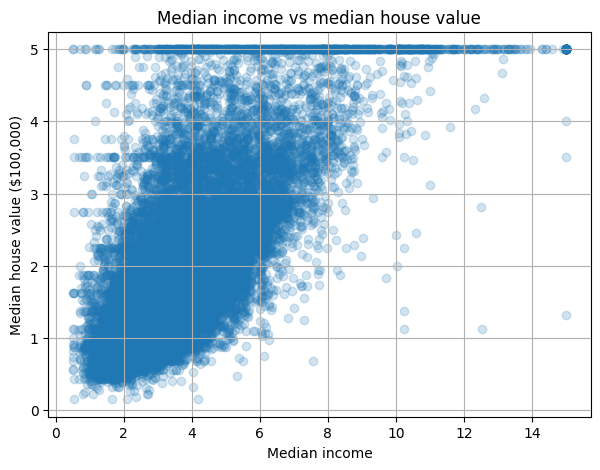

In [15]:
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.2)
plt.xlabel("Median income")
plt.ylabel("Median house value ($100,000)")
plt.title("Median income vs median house value")
plt.show()

The plot suggests that districts with higher median income tend to have higher median house values.

But the relationship is not perfect. Machine learning is usually about using imperfect information to make useful predictions.

In [16]:
corr_with_target = df.corr(numeric_only=True)["MedHouseVal"].sort_values(ascending=False)
corr_with_target

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


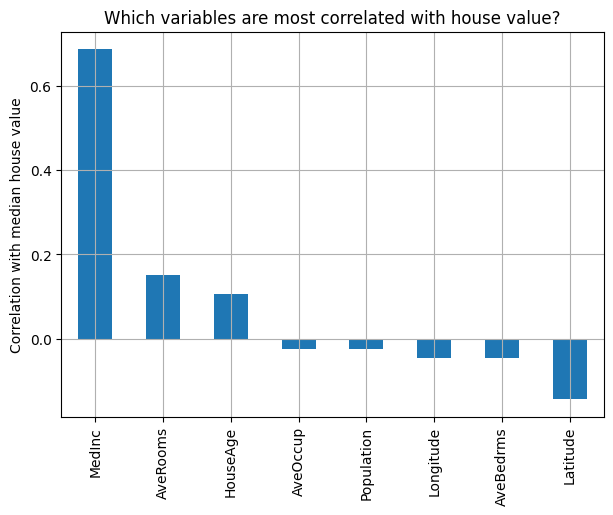

In [17]:
corr_with_target.drop("MedHouseVal").plot(kind="bar")
plt.ylabel("Correlation with median house value")
plt.title("Which variables are most correlated with house value?")
plt.show()

## Activity 2

Explore the relationship between house value and other variables.

1. Create a scatterplot of `AveRooms` against `MedHouseVal`.
2. Create a scatterplot of `HouseAge` against `MedHouseVal`.
3. Create a scatterplot of `Latitude` against `MedHouseVal`.
4. Which variable seems most useful for prediction?
5. Which variable seems hard to interpret on its own?

For each plot, try to write one sentence interpreting what you see.

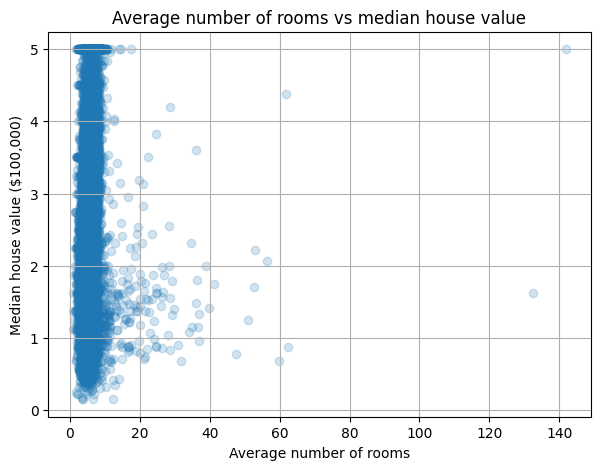

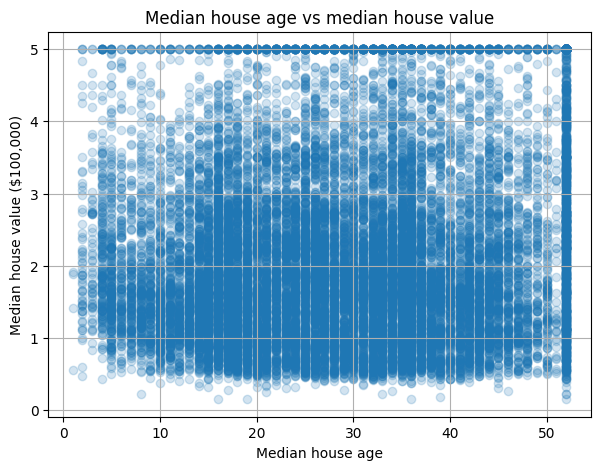

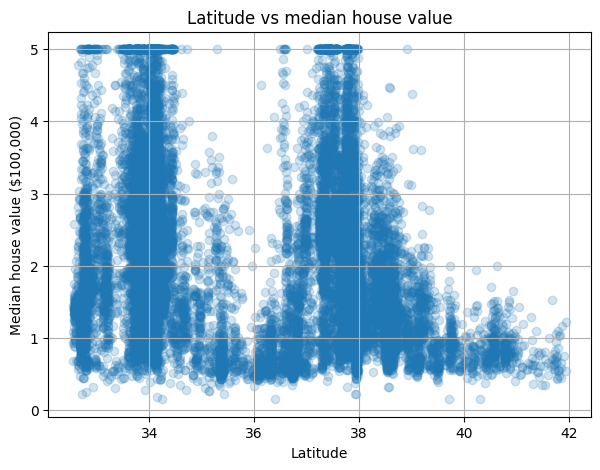

AveRooms seems most useful for prediction.
HouseAge seems hard to interpret on its own.


In [18]:
# Add your own plots here

#Create a scatterplot of AveRooms against MedHouseVal.
plt.scatter(df["AveRooms"], df["MedHouseVal"], alpha=0.2)
plt.xlabel("Average number of rooms")
plt.ylabel("Median house value ($100,000)")
plt.title("Average number of rooms vs median house value")
plt.show()

#Create a scatterplot of HouseAge against MedHouseVal.
plt.scatter(df["HouseAge"], df["MedHouseVal"], alpha=0.2)
plt.xlabel("Median house age")
plt.ylabel("Median house value ($100,000)")
plt.title("Median house age vs median house value")
plt.show()

#Create a scatterplot of Latitude against MedHouseVal.
plt.scatter(df["Latitude"], df["MedHouseVal"], alpha=0.2)
plt.xlabel("Latitude")
plt.ylabel("Median house value ($100,000)")
plt.title("Latitude vs median house value")
plt.show()

#Which variable seems most useful for prediction?
print("AveRooms seems most useful for prediction.")

#Which variable seems hard to interpret on its own?
print("HouseAge seems hard to interpret on its own.")

### Optional: location matters

For students who are more comfortable with Python, try the plot below and interpret it.

What do `Latitude` and `Longitude` reveal that the other variables do not?

# Cycle 3: A first machine learning workflow

We now complete a very simple prediction workflow.

The model will use only one predictor:

\[
\text{Median income} \rightarrow \text{Median house value}.
\]

This is deliberately simple. We will study linear regression properly in the next lectures.

## Demonstration: train-test split

To estimate how well a model generalises, we split the data into:

- a **training set**, used to fit the model;
- a **test set**, used to evaluate predictions on data the model has not seen.

In [19]:
X_simple = df[["MedInc"]]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.25, random_state=123
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 15480
Test set size: 5160


## Demonstration: fit a simple linear regression

We now fit a straight-line model using the training data.

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 0.45056806499578483
Slope: 0.41887110821806955


The fitted model has the form:

$$
\widehat{\text{MedHouseVal}} = \hat\beta_0 + \hat\beta_1 \times \text{MedInc}.
$$

We are not deriving the formula today. The key point is that the model has learned a simple relationship from the training data.

In [21]:
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test R-squared:", r2)

Test RMSE: 0.6969729098411372
Test R-squared: 0.47068056512968104


The RMSE is measured in units of 100,000. For example, an RMSE of 0.8 corresponds to an error of roughly 80,000.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


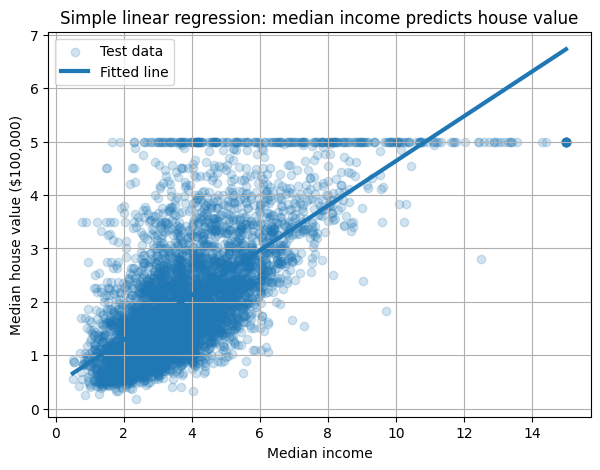

In [22]:
x_grid = np.linspace(df["MedInc"].min(), df["MedInc"].max(), 200).reshape(-1, 1)
y_grid = model.predict(x_grid)

plt.scatter(X_test["MedInc"], y_test, alpha=0.2, label="Test data")
plt.plot(x_grid, y_grid, linewidth=3, label="Fitted line")
plt.xlabel("Median income")
plt.ylabel("Median house value ($100,000)")
plt.title("Simple linear regression: median income predicts house value")
plt.legend()
plt.show()

## Activity 3

Now repeat the workflow using a different single predictor.

Try one of:

- `AveRooms`
- `HouseAge`
- `Latitude`
- `AveOccup`

For each predictor:

1. Split the data into training and test sets.
2. Fit a simple linear regression.
3. Compute the test RMSE.
4. Compare it with the RMSE from `MedInc`.
5. Decide which single predictor you would prefer.


--- Running workflow for: AveRooms ---
Training set size: 15480
Test set size: 5160
Test MSE for AveRooms: 1.2858


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


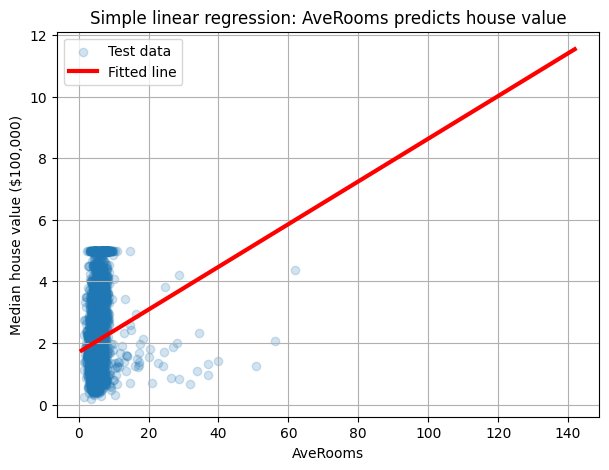


--- Running workflow for: HouseAge ---
Training set size: 15480
Test set size: 5160
Test MSE for HouseAge: 1.2986


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


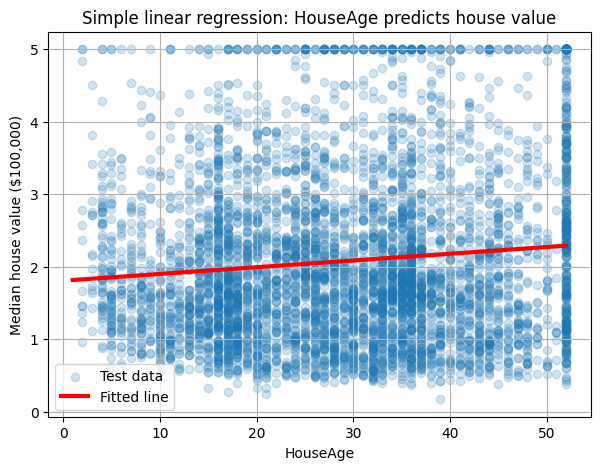


--- Running workflow for: Latitude ---
Training set size: 15480
Test set size: 5160
Test MSE for Latitude: 1.2948


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


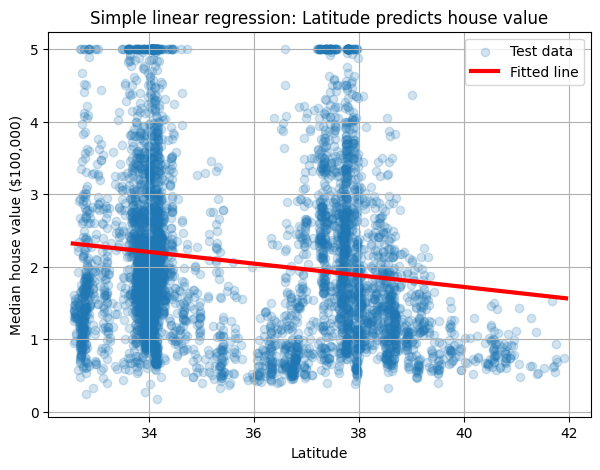


--- Running workflow for: AveOccup ---
Training set size: 15480
Test set size: 5160
Test MSE for AveOccup: 1.3159


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


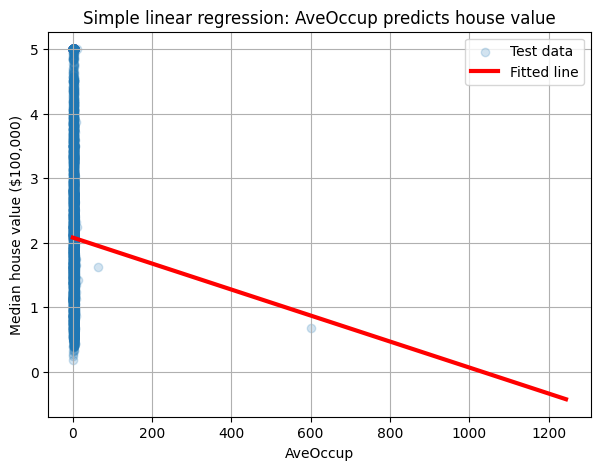


--- Comparison of MSE results ---
MedInc: 0.6970
AveRooms: 1.2858
HouseAge: 1.2986
Latitude: 1.2948
AveOccup: 1.3159

Based on the test MSE, the preferred single predictor is: MedInc


In [23]:
predictors = ["AveRooms", "HouseAge", "Latitude", "AveOccup"]

# Store MSE results for comparison
mse_results = {"MedInc": 0.6969729098411372} # The original MSE from MedInc

for predictor in predictors:
    print(f"\n--- Running workflow for: {predictor} ---")

    # 1. Split the data into training and test sets.
    X_single_predictor = df[[predictor]]
    y = df["MedHouseVal"]

    X_train, X_test, y_train, y_test = train_test_split(
        X_single_predictor, y, test_size=0.25, random_state=123
    )

    print(f"Training set size: {X_train.shape[0]}")
    print(f"Test set size: {X_test.shape[0]}")

    # 2. Fit a simple linear regression.
    model = LinearRegression()
    model.fit(X_train, y_train)

    # 3. Compute the test MSE (RMSE was used loosely before, so we stick to MSE for consistency).
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_results[predictor] = mse

    print(f"Test MSE for {predictor}: {mse:.4f}")

    # Plotting for visual interpretation (optional, but good for activity)
    x_grid = np.linspace(df[predictor].min(), df[predictor].max(), 200).reshape(-1, 1)
    y_grid = model.predict(x_grid)

    plt.scatter(X_test[predictor], y_test, alpha=0.2, label="Test data")
    plt.plot(x_grid, y_grid, linewidth=3, label="Fitted line", color='red')
    plt.xlabel(predictor)
    plt.ylabel("Median house value ($100,000)")
    plt.title(f"Simple linear regression: {predictor} predicts house value")
    plt.legend()
    plt.show()

print("\n--- Comparison of MSE results ---")
for pred, mse_val in mse_results.items():
    print(f"{pred}: {mse_val:.4f}")

# 5. Decide which single predictor you would prefer.
min_mse_predictor = min(mse_results, key=mse_results.get)
print(f"\nBased on the test MSE, the preferred single predictor is: {min_mse_predictor}")

### Discussion

- Which predictor gave the best test RMSE?
- Did the scatterplots help you anticipate this?
- Is a straight line a good model for all predictors?
- What would you try next?

# Optional extension: for students with more Python experience

These tasks are not required, but they are useful if you are already comfortable with Python.

## Extension A: Multiple regression

Fit a model using several predictors at the same time.

Suggested predictors:

```python
["MedInc", "AveRooms", "HouseAge", "Latitude", "Longitude"]
```

Compare the test RMSE with the simple one-predictor model.

## Extension B: Create a new feature

Create a variable called `RoomsPerPerson`:

$$
\text{RoomsPerPerson} = \frac{\text{AveRooms}}{\text{AveOccup}}.
$$

Does this improve prediction when added to the model?

## Extension C: Training error vs test error

Compute both training RMSE and test RMSE for the multiple regression model.

Are they similar? What would it mean if training error were much smaller than test error?

# Wrap-up

Today you completed a full machine learning workflow:

1. Defined a prediction problem.
2. Loaded and explored data.
3. Chose features.
4. Split the data into training and test sets.
5. Fitted a simple model.
6. Made predictions.
7. Evaluated performance.

The details of linear regression, likelihood, estimation and regularisation will come next. The workflow will stay the same.